# Taller modelos lineales de clasificación - Regresión logística

Sintonice y enrene un modelo de regresión logística para predecir la variable `Churn Label` del dataset **"telco-customer-churn.csv"**, cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Elimine variables que son claves primaria y que son constantes. También elimine las siguientes variables: Lat Long, Churn Value, Churn Reason, Churn Score.

## Modelo 1

Debe usar `Pipeline` y `ColumnTransformer` para crear un flujo que integre el procesamiento de los datos y el modelado, de manera que evite la fuga de datos.

El procesamiento de los datos debe incluir las siguientes transformaciones:
- Estandarización de variables numéricas
- Imputación de datos nulos
- Codificación de variables categóricas

Escoja una métrica que priorice la clasificación correcta de los clientes que se retiran. Con esta métrica sintonice `C` y `l1_ratio`.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

## Modelo 2

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

Vuelva a entrenar y sintonizar el modelo, pero ahora seleccione una métrica que priorice etiquetar correctamente a los clientes que no se han retirado.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

**Advertencia:** El entrenamiento de los modelos puede tardar más de 10 minutos. No se preocupe, este es normal. Para reducir un poco el tiempo de entrenamiento pruebe solo 20 valores de `C` y 5 de `l1_ratio`.


In [16]:
from pathlib import Path

import pandas as pd
    
ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv' 

df = pd.read_csv(DATA_DIR / file_path, na_values=[' ?', ' '])
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [18]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [19]:
df = df.drop(columns=['CustomerID','Country','State','Lat Long', 'Churn Value', 'Churn Reason', 'Churn Score'])

In [20]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   City               7043 non-null   object 
 2   Zip Code           7043 non-null   int64  
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   object 
 6   Senior Citizen     7043 non-null   object 
 7   Partner            7043 non-null   object 
 8   Dependents         7043 non-null   object 
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   object 
 11  Multiple Lines     7043 non-null   object 
 12  Internet Service   7043 non-null   object 
 13  Online Security    7043 non-null   object 
 14  Online Backup      7043 non-null   object 
 15  Device Protection  7043 non-null   object 
 16  Tech Support       7043 

# Neithan Felipe Gomez Rivera

# Phol Castañeda Henao

# Daniela Higuita Agudelo

## Modelo 1



In [21]:
from sklearn.model_selection import train_test_split

X = df.drop([
    'Churn Label',
    ], axis=1)

y = df['Churn Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)  # noqa: E501
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (5634, 25)
Tamaño del conjunto de prueba es: (1409, 25)


In [22]:
X_train

,Count,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
1814,1,El Monte,91732,34.074492,-118.014620,Female,No,No,No,37,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),101.90,3545.35,4437
5946,1,Tustin,92780,33.735802,-117.818805,Male,No,Yes,Yes,68,...,No,No,Yes,No,One year,No,Mailed check,44.80,2983.65,4112
3881,1,Woodacre,94973,38.005839,-122.638155,Male,No,Yes,Yes,62,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.95,1244.80,4803
2389,1,Woody,93287,35.710244,-118.881679,Female,No,Yes,No,1,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.65,20.65,4517
3676,1,Clovis,93611,36.917652,-119.593757,Female,Yes,No,No,2,...,No,No,Yes,No,Month-to-month,No,Mailed check,81.50,162.55,4267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,1,Long Beach,90814,33.771612,-118.143866,Male,No,No,No,7,...,No,No,No,Yes,Month-to-month,Yes,Mailed check,85.20,602.55,3905
5192,1,Le Grand,95333,37.249377,-120.249581,Male,No,No,No,37,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.15,785.75,4422
3980,1,Manteca,95336,37.830267,-121.201018,Male,No,Yes,Yes,42,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,867.30,3433
235,1,San Francisco,94131,37.746699,-122.442833,Female,No,No,No,13,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.15,952.30,4806


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
oe_contract = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
oe_internet = OrdinalEncoder(categories=[['No', 'DSL', 'Fiber optic']])
ss = StandardScaler()
target_enc = TargetEncoder()

imputer = SimpleImputer(strategy='mean')

proc_num = Pipeline([
    ('imputer', imputer),
    ('ss', ss)
])

preprocessor = ColumnTransformer(transformers=[
    
    ('ohe', ohe, [
        'Gender', 'Partner', 'Dependents',
        'Phone Service', 'Multiple Lines',
        'Online Security', 'Online Backup',
        'Device Protection', 'Tech Support',
        'Streaming TV', 'Streaming Movies',
        'Paperless Billing', 'Payment Method'
    ]),  
    
    ('target_enc', target_enc, ['City']), 
    
    ('oe_contract', oe_contract, ['Contract']), 
    ('oe_internet', oe_internet, ['Internet Service']), 
    
    ('proc_num', proc_num, [
        'Tenure Months', 'Monthly Charges', 'Total Charges'
    ])
    
],
remainder='drop')  

preprocessor

,transformers,"[('ohe', ...), ('target_enc', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = LogisticRegression(
        #penalty='elasticnet',
        max_iter=10000,
        solver='saga'
        )

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('target_enc', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import recall_score, make_scorer, classification_report, confusion_matrix

grid = {
    #'penalty':['l1', 'l2', 'elasticnet'], # tipo de regularización
    'clf__C':np.logspace(-3,3,20), # inverso del factor de regularización
    'clf__l1_ratio':[0, 0.1, 0.5, 0.9, 1] # si tipo de regularización es elasticnet, define que tanto peso se la da a cada tipo de regularización
    }

scoring = make_scorer(recall_score, pos_label=1)


grid_search = GridSearchCV(
    estimator=model,
    param_grid=grid,
    #cv=5,
    scoring=scoring
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

grid_search.fit(X_train, y_train)
#train_score = precision_score(y_train, grid_search.best_estimator_.predict(X_train))
#test_score = precision_score(y_test, grid_search.best_estimator_.predict(X_test))

print(f'Cross-validation score: {grid_search.best_score_:.3f}, best hyperparameters: {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train):.3f}')
print(f'Test score: {grid_search.score(X_test, y_test):.3f}')

/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/n

Cross-validation score: 0.587, best hyperparameters: {'clf__C': np.float64(483.2930238571752), 'clf__l1_ratio': 0.5}
Train score: 0.595
Test score: 0.571


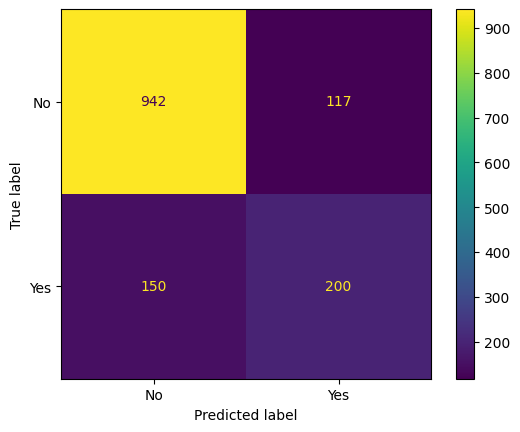

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

          No       0.86      0.89      0.88      1059
         Yes       0.63      0.57      0.60       350

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



### Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?


R/
¿El modelo está bien ajustado, sobreajustado o subajustado?
R/ Se ha realizado una partición de los datos utilizando una proporción de 80% para entrenamiento (5,634 registros) y 20% para validación/prueba (1,409 registros).
El tamaño del conjunto de entrenamiento (5,634 muestras) es adecuado para una regresión logística con 25 variables predictoras. Al mantener un conjunto de prueba del 20%, reducimos el riesgo de sobreajuste (overfitting).

¿El modelo está balanceado?
R/ Al verificar con lo siguiente:

y.value_counts(normalize=True)

El modelo no está balanceado. Esto se evidencia en la distribución de la variable objetivo, donde aproximadamente el 73.46% de los datos corresponden a la clase “No” (clientes que no abandonan) y solo el 26.54% a la clase “Yes” (clientes que abandonan). Esta diferencia indica un desbalance en el dataset.
Además, el classification_report confirma este comportamiento, ya que el modelo presenta un mejor desempeño en la clase mayoritaria (“No”), con un recall de 0.89, mientras que para la clase minoritaria (“Yes”) el recall es menor (0.57). Esto significa que el modelo identifica mejor a los clientes que permanecen que a los que abandonan.

¿Con qué clase tiene mejor desempeño?
R/ El modelo tiene mejor desempeño en la clase “No”, ya que presenta métricas más altas (recall 0.89 y f1-score 0.88) en comparación con la clase “Yes”, donde el desempeño es menor (recall 0.57). Esto indica que predice mejor a los clientes que no abandonan.

## Modelo 2

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

Vuelva a entrenar y sintonizar el modelo, pero ahora seleccione una métrica que priorice etiquetar correctamente a los clientes que no se han retirado.

Reporte:

- los resultados de las métricas de validación, entrenamiento y prueba.
- los valores de los hiperparámetros sintonizados.
- la matriz de confusión.
- el reporte de clasificación.

Analice los resultados obtenidos. ¿El modelo esta correctamente ajustado, o está sobreajustado o subajustado? ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes de este último modelo. ¿Cuáles son las 5 características más importantes de su modelo?

**Advertencia:** El entrenamiento de los modelos puede tardar más de 10 minutos. No se preocupe, este es normal. Para reducir un poco el tiempo de entrenamiento pruebe solo 20 valores de `C` y 5 de `l1_ratio`.

In [ ]:
# Accede al clasificador dentro del pipeline
modelo_final = grid_search.best_estimator_.named_steps['clf']

columnas_transformadas = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
pesos = pd.DataFrame(modelo_final.coef_, columns=columnas_transformadas, index=['Pesos'])
pesos['intercept'] = modelo_final.intercept_
pesos.T.sort_values('Pesos', ascending=False)

,Pesos
oe_internet__Internet Service,1.155678
proc_num__Total Charges,0.527954
ohe__Streaming Movies_Yes,0.443331
ohe__Streaming TV_Yes,0.348598
ohe__Multiple Lines_Yes,0.337734
ohe__Paperless Billing_Yes,0.334207
ohe__Payment Method_Electronic check,0.318702
ohe__Partner_Yes,0.308345
target_enc__City,0.175744
ohe__Device Protection_Yes,0.007956


In [31]:
# 2. Identificar las 5 características más importantes
# Usamos el valor absoluto para ver importancia real (tanto positiva como negativa)
importancia = pesos.T.drop('intercept').copy()
importancia['Abs_Pesos'] = importancia['Pesos'].abs()
top_5 = importancia.sort_values('Abs_Pesos', ascending=False).head(5)

print("Las 5 características más importantes son:")
print(top_5[['Pesos']])

Las 5 características más importantes son:
                                         Pesos
ohe__Dependents_Yes                  -1.571449
proc_num__Tenure Months              -1.318290
oe_internet__Internet Service         1.155678
ohe__Phone Service_Yes               -1.069971
ohe__Multiple Lines_No phone service -0.863822


In [32]:
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

recall_clase_0 = make_scorer(recall_score, pos_label=0)

grid_search_v2 = GridSearchCV(
    model,  # Tu pipeline original
    param_grid={
        'clf__C': np.logspace(-3, 3, 20),
        'clf__l1_ratio': np.linspace(0, 1, 5),
        'clf__penalty': ['elasticnet']
    },
    scoring=recall_clase_0,
    cv=5,
    n_jobs=-1
)

grid_search_v2.fit(X_train, y_train)

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'clf__C': array([1.0000...00000000e+03]), 'clf__l1_ratio': array([0. , ..., 0.75, 1. ]), 'clf__penalty': ['elasticnet']}"
,scoring,"make_scorer(r..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('target_enc', ...), ...]"


Mejores parámetros: {'clf__C': np.float64(0.001), 'clf__l1_ratio': np.float64(0.25), 'clf__penalty': 'elasticnet'}

--- Reporte de Clasificación (Prueba) ---
              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1059
           1       0.00      0.00      0.00       350

    accuracy                           0.75      1409
   macro avg       0.38      0.50      0.43      1409
weighted avg       0.56      0.75      0.65      1409


--- Matriz de Confusión ---


/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/neithan/Desktop/Fork de analisis predictivo/ap-2026-1-62/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa


Accuracy Entrenamiento: 0.7304
Accuracy Prueba: 0.7516


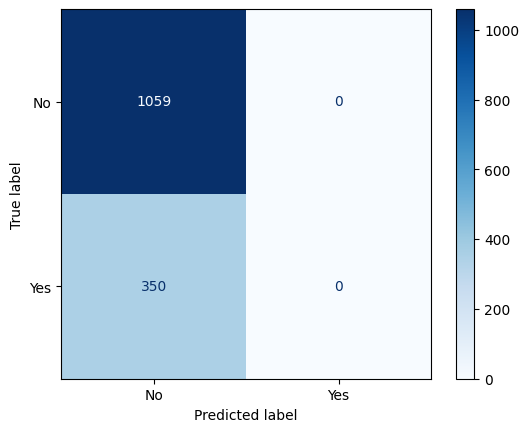

In [34]:
# Mejores hiperparámetros
print(f"Mejores parámetros: {grid_search_v2.best_params_}")

# Predicciones
y_pred_train = grid_search_v2.predict(X_train)
y_pred_test = grid_search_v2.predict(X_test)

# Reporte de Clasificación
print("\n--- Reporte de Clasificación (Prueba) ---")
print(classification_report(y_test, y_pred_test))

# 3. Matriz de Confusión con el formato solicitado
print("\n--- Matriz de Confusión ---")
ConfusionMatrixDisplay.from_estimator(
    grid_search_v2.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap='Blues' # Opcional: añade color para mejor lectura
);

# Métricas de comparación
from sklearn.metrics import accuracy_score
print(f"\nAccuracy Entrenamiento: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy Prueba: {accuracy_score(y_test, y_pred_test):.4f}")